# Multi-Index Fast Gaussian Process

## Setup

In [1]:
import fastgp
from mlqmcpy.problems.elliptic import solve_elliptic_pde

In [2]:
import torch
torch.set_default_dtype(torch.float64)

In [3]:
import matplotlib 
from matplotlib import pyplot,cm,colors
from tueplots import bundles
#pyplot.rcParams.update(bundles.icml2022())
COLORS = ['xkcd:purple', 'xkcd:green', 'xkcd:blue', 'xkcd:red', 'xkcd:turquoise', 'xkcd:pink', 'xkcd:brown', 'xkcd:light blue', 'xkcd:teal', 'xkcd:orange']
pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
WIDTH = 2*(500/72)

## Parameters

In [4]:
confidence = .99 
budget = 10000
d = 5
num_levels = 3
cost_per_level = 2.**(torch.arange(num_levels)-num_levels+1)
print("cost_per_level = %s"%cost_per_level)
m0 = 8*torch.ones(num_levels,dtype=int)
n0 = 2**m0
print("n0 = %s"%n0)
initial_cost = (n0*cost_per_level).sum()
print("initial_cost = %.1f"%initial_cost)
remaining_budget = budget-initial_cost
print("remaining_budget = %.1f"%remaining_budget)

cost_per_level = tensor([0.2500, 0.5000, 1.0000])
n0 = tensor([256, 256, 256])
initial_cost = 448.0
remaining_budget = 9552.0


## Initial Sampling

In [5]:
fgp = fastgp.FastGPDigitalNetB2(d,seed_for_seq=7,num_tasks=num_levels)
x0s = fgp.get_x_next(n0)
y0s = [torch.tensor([solve_elliptic_pde(level=l,coeffs=x[i].numpy())[0] for i in range(n0[l])]) for l,x in enumerate(x0s)]
fgp.add_y_next(y0s)
data0 = fgp.fit()
print("data")
for l in range(num_levels):
    print("\tx0s[%d].shape = %s"%(l,str(x0s[l].shape)))
    print("\ty0s[%d].shape = %s"%(l,str(y0s[l].shape)))
    print()
pcmean0,pcvar0,_,pcci_low0,pcci_high0 = fgp.post_cubature_ci(task=num_levels-1,confidence=confidence)
pcerror0 = (pcci_high0-pcci_low0)/2
print("pcmean0 = %.5f"%pcmean0)
print("pcvar0 = %.2e"%pcvar0)
print("pcci0 = [%.2e , %.2e]"%(pcci_low0,pcci_high0))
print("pcerror0 = %.2e"%pcerror0)

     iter of 5.0e+03 | NMLL       | norm term  | logdet term
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 5.44e+03   | 4.42e-02   | 4.03e+03  
            5.00e+00 | 2.31e+03   | 1.50e+00   | 8.94e+02  
            1.00e+01 | -2.07e+03  | 1.32e+03   | -4.80e+03 
            1.50e+01 | -3.13e+03  | 8.20e+02   | -5.36e+03 
            2.00e+01 | -3.43e+03  | 8.81e+02   | -5.72e+03 
            2.50e+01 | -3.48e+03  | 8.13e+02   | -5.71e+03 
            3.00e+01 | -3.49e+03  | 9.11e+02   | -5.81e+03 
            3.50e+01 | -3.50e+03  | 8.24e+02   | -5.73e+03 
            4.00e+01 | -3.50e+03  | 7.73e+02   | -5.69e+03 
            4.50e+01 | -3.50e+03  | 7.90e+02   | -5.71e+03 
            5.00e+01 | -3.51e+03  | 7.84e+02   | -5.71e+03 
            5.50e+01 | -3.51e+03  | 8.43e+02   | -5.76e+03 
            6.00e+01 | -3.51e+03  | 7.93e+02   | -5.72e+03 
            6.50e+01 | -3.51e+03  | 7.71e+02   | -5.70e+03 
            7.00e+01 | -3.51e+03  | 7.

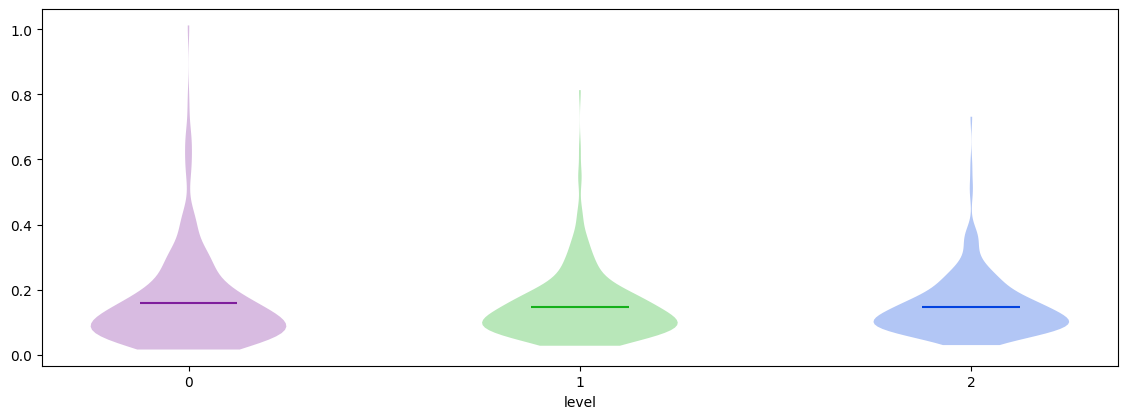

In [6]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(WIDTH,WIDTH/num_levels))
for l in range(num_levels):
    ax.violinplot(fgp.y[l],[l],showmeans=True,showextrema=False)
ax.set_xlabel("level")
ax.set_xticks(torch.arange(num_levels));

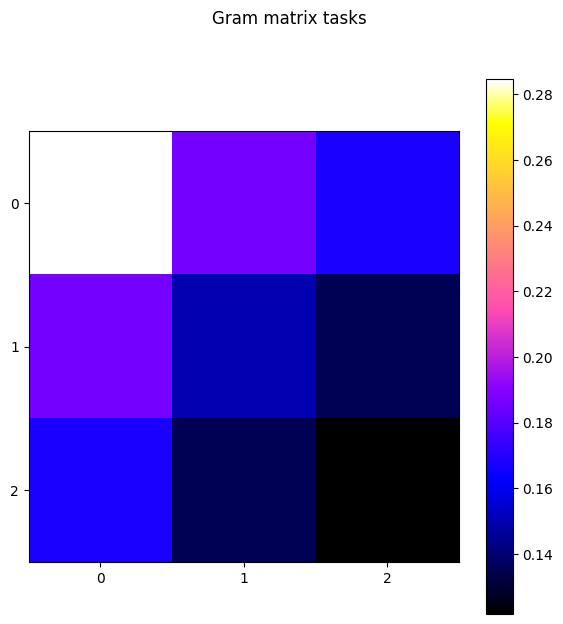

In [7]:
SPACING = .25
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(WIDTH/2,WIDTH/2))
_imshow = ax.imshow(fgp.gram_matrix_tasks.detach(),cmap=cm.gnuplot2)
fig.colorbar(_imshow)
ax.set_xticks(torch.arange(num_levels))
ax.set_yticks(torch.arange(num_levels))
fig.suptitle("Gram matrix tasks");

## Projections

In [8]:
print("n0 = %s"%n0)
nnew_max = (remaining_budget/cost_per_level).floor().to(int)
print("nnew_max = %s"%nnew_max)
m_max = torch.log2(n0+nnew_max).floor().to(int)
n_max = 2**m_max
print("n_max = %s"%n_max)
assert (n_max>n0).all(), "must have a large enough budget to at least double the same size on the finest level"

n0 = tensor([256, 256, 256])
nnew_max = tensor([38208, 19104,  9552])
n_max = tensor([32768, 16384,  8192])


In [9]:
m_feasible = [torch.arange(m0[l]+1,m_max[l]+1) for l in range(num_levels)]
num_m_feasible = torch.tensor([len(m_feasible[l]) for l in range(num_levels)])
for l in range(num_levels):
    print("m_feasible[%d] = %-50s has length %d"%(l,m_feasible[l],num_m_feasible[l]))
num_feasible_combs = num_m_feasible.prod()
print("num_feasible_combs = %d"%num_feasible_combs)

m_feasible[0] = tensor([ 9, 10, 11, 12, 13, 14, 15])               has length 7
m_feasible[1] = tensor([ 9, 10, 11, 12, 13, 14])                   has length 6
m_feasible[2] = tensor([ 9, 10, 11, 12, 13])                       has length 5
num_feasible_combs = 210


In [10]:
mfmesh = torch.meshgrid(*m_feasible,indexing="ij")
mf_comb = torch.vstack([mfmesh_l.flatten() for mfmesh_l in mfmesh]).T
nf_comb = 2**mf_comb
print("nf_comb.shape = %s"%str(nf_comb.shape))
nf_comb_cost = (nf_comb*cost_per_level).sum(1)
feasible_comb = nf_comb_cost<budget
print("feasible_comb.shape = %s"%str(feasible_comb.shape))
mf_comb_feasible = mf_comb[feasible_comb]
print("mf_comb_feasible.shape = %s"%str(mf_comb_feasible.shape))
mf_comb_infeasible = mf_comb[~feasible_comb]
print("mf_comb_infeasible.shape = %s"%str(mf_comb_infeasible.shape))

nf_comb.shape = torch.Size([210, 3])
feasible_comb.shape = torch.Size([210])
mf_comb_feasible.shape = torch.Size([139, 3])
mf_comb_infeasible.shape = torch.Size([71, 3])


In [11]:
# should be done more efficiently by only considering the boundary 
pcerrors = torch.tensor([fgp.post_cubature_error(task=(num_levels-1),n=nf_comb[i],confidence=confidence)[2] for i in range(len(nf_comb))])
print("pcerrors.shape = %s"%str(pcerrors.shape))
imin = pcerrors[feasible_comb].argmin()
pcerrors_min = pcerrors[feasible_comb][imin]
print("pcerrors_min = %.2e"%pcerrors_min)
n = nf_comb[feasible_comb][imin]
print("n = %s"%n)

pcerrors.shape = torch.Size([210])
pcerrors_min = 1.79e-03
n = tensor([16384,  2048,  4096])


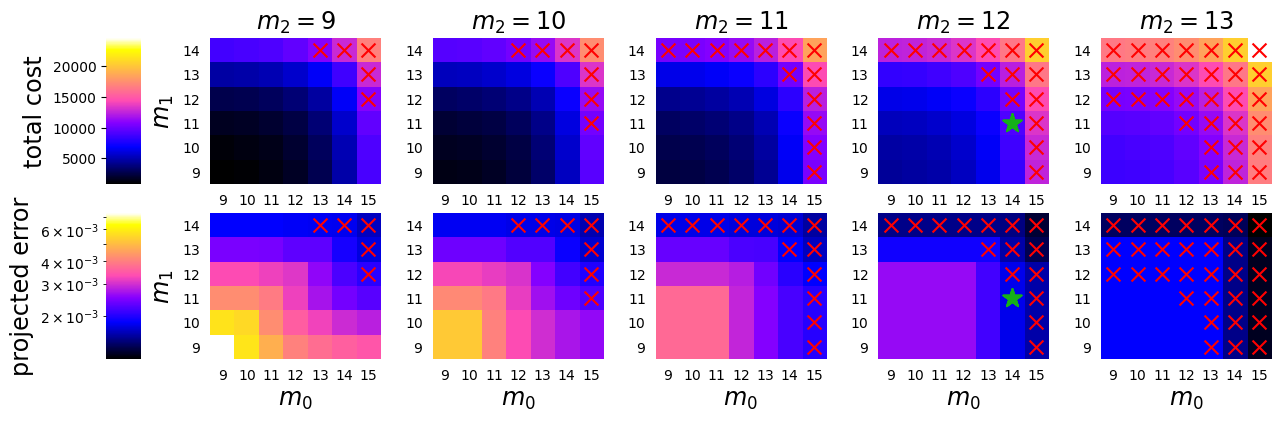

In [12]:
cost_min,cost_max = nf_comb_cost.min(),nf_comb_cost.max()
pcerror_min,pcerror_max = pcerrors.min(),pcerrors.max()
if num_levels==2:
    fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(WIDTH,WIDTH/2))
    _imshow_cost = ax[0].imshow(nf_comb_cost.reshape((num_m_feasible[0],num_m_feasible[1])).T,cmap=cm.gnuplot2,vmin=cost_min,vmax=cost_max)
    _imshow_error = ax[1].imshow(pcerrors.reshape((num_m_feasible[0],num_m_feasible[1])).T,cmap=cm.gnuplot2,vmin=pcerror_min,vmax=pcerror_max,norm="log")
    for i,(_imshow,label) in enumerate(zip([_imshow_cost,_imshow_error],["total cost","projected error"])):
        _axp = ax[i].get_position()
        _cax = fig.add_axes([_axp.x0,_axp.y1+0.05,_axp.x1-_axp.x0,0.05])
        cbar = fig.colorbar(_imshow,_cax,location="top")
        cbar.set_label(label=label,fontsize="xx-large")
        cbar.outline.set_visible(False)
    for i in range(2):
        ax[i].set_xlabel(r"$m_0$",fontsize="xx-large")
        ax[i].scatter(mf_comb_feasible[imin,0]-(m0[0]+1),mf_comb_feasible[imin,1]-(m0[1]+1),color=COLORS[1],marker="*",s=200)
        ax[i].scatter(mf_comb_infeasible[:,0]-(m0[0]+1),mf_comb_infeasible[:,1]-(m0[1]+1),marker="x",s=100,color="red")
        ax[i].spines[["right","left","top","bottom"]].set_visible(False)
        ax[i].invert_yaxis()
        ax[i].set_xticks(torch.arange(len(m_feasible[0])))
        ax[i].set_xticklabels([r"$%d$"%_m for _m in m_feasible[0]])
        ax[i].xaxis.set_ticks_position('none') 
        ax[i].set_yticks(torch.arange(len(m_feasible[1])))
        ax[i].set_yticklabels([r"$%d$"%_m for _m in m_feasible[1]])
        ax[i].yaxis.set_ticks_position('none') 
    ax[0].set_ylabel(r"$m_1$",fontsize="xx-large")
elif num_levels==3:
    ncols = len(m_feasible[-1])
    fig,ax = pyplot.subplots(nrows=2,ncols=ncols,figsize=(WIDTH,WIDTH*.75/ncols*2))
    ax = ax.reshape((2,ncols))
    for j in range(ncols):
        _imshow_cost = ax[0,j].imshow(nf_comb_cost[j::num_m_feasible[2]].reshape((num_m_feasible[0],num_m_feasible[1])).T,cmap=cm.gnuplot2,vmin=cost_min,vmax=cost_max)
        _imshow_error = ax[1,j].imshow(pcerrors[j::num_m_feasible[2]].reshape((num_m_feasible[0],num_m_feasible[1])).T,cmap=cm.gnuplot2,vmin=pcerror_min,vmax=pcerror_max,norm="log")
    for i,(_imshow,label) in enumerate(zip([_imshow_cost,_imshow_error],["total cost","projected error"])):
        _axp = ax[i,0].get_position()
        _cax = fig.add_axes([_axp.x0-.075,_axp.y0,0.025,_axp.y1-_axp.y0])
        cbar = fig.colorbar(_imshow,_cax,location="left")
        cbar.set_label(label=label,fontsize="xx-large")
        cbar.outline.set_visible(False)
    for j in range(ncols):
        ax[1,j].set_xlabel(r"$m_0$",fontsize="xx-large")
        ax[0,j].set_title(r"$m_2 = %d$"%m_feasible[2][j],fontsize="xx-large")
    for i in range(2):
        ax[i,0].set_ylabel(r"$m_1$",fontsize="xx-large")
        for j in range(ncols):
            ax[i,j].spines[["right","left","top","bottom"]].set_visible(False)
            ax[i,mf_comb_feasible[imin,2]-(m0[2]+1)].scatter(mf_comb_feasible[imin,0]-(m0[0]+1),mf_comb_feasible[imin,1]-(m0[1]+1),color=COLORS[1],marker="*",s=200)
            mf_comb_infeasible_j = mf_comb_infeasible[mf_comb_infeasible[:,2]==(m0[2]+1+j)]
            ax[i,j].scatter(mf_comb_infeasible_j[:,0]-(m0[0]+1),mf_comb_infeasible_j[:,1]-(m0[1]+1),marker="x",s=100,color="red")
            ax[i,j].invert_yaxis()
            ax[i,j].set_xticks(torch.arange(len(m_feasible[0])))
            ax[i,j].set_xticklabels([r"$%d$"%_m for _m in m_feasible[0]])
            ax[i,j].xaxis.set_ticks_position('none') 
            ax[i,j].set_yticks(torch.arange(len(m_feasible[1])))
            ax[i,j].set_yticklabels([r"$%d$"%_m for _m in m_feasible[1]])
            ax[i,j].yaxis.set_ticks_position('none') 
else:
    print("cannot plot num_levels > 2")

## Final Sampling

In [13]:
# running this cell multiple times will give errors as it tries to keep adding more and more samples 
xs = fgp.get_x_next(n)
ys = [torch.tensor([solve_elliptic_pde(level=l,coeffs=x[i].numpy())[0] for i in range(n[l]-n0[l])]) for l,x in enumerate(xs)]
fgp.add_y_next(ys)
data = fgp.fit()
print("data")
for l in range(num_levels):
    print("\txs[%d].shape = %s"%(l,str(xs[l].shape)))
    print("\tys[%d].shape = %s"%(l,str(ys[l].shape)))
    print()
print("pcmean0 = %.5f"%pcmean0)
print("pcvar0 = %.2e"%pcvar0)
print("pcci0 = [%.2e , %.2e]"%(pcci_low0,pcci_high0))
print("pcerror0 = %.2e"%pcerror0)
print()
print("pcerrors_min = %.2e"%pcerrors_min)
print()
pcmean,pcvar,_,pcci_low,pcci_high = fgp.post_cubature_ci(task=num_levels-1,confidence=0.99)
pcerror = (pcci_high-pcci_low)/2
print("pcmean = %.5f"%pcmean)
print("pcvar = %.2e"%pcvar)
print("pcci = [%.2e , %.2e]"%(pcci_low,pcci_high))
print("pcerror = %.2e"%pcerror)

     iter of 5.0e+03 | NMLL       | norm term  | logdet term
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | -1.19e+05  | 5.28e+04   | -2.13e+05 
            5.00e+00 | -1.30e+05  | 1.85e+04   | -1.90e+05 
            1.00e+01 | -1.31e+05  | 1.78e+04   | -1.90e+05 
            1.50e+01 | -1.32e+05  | 2.19e+04   | -1.95e+05 
            2.00e+01 | -1.32e+05  | 2.25e+04   | -1.96e+05 
            2.50e+01 | -1.32e+05  | 2.23e+04   | -1.96e+05 
            3.00e+01 | -1.32e+05  | 2.24e+04   | -1.96e+05 
            3.50e+01 | -1.32e+05  | 2.24e+04   | -1.96e+05 
            4.00e+01 | -1.32e+05  | 2.31e+04   | -1.96e+05 
            4.50e+01 | -1.32e+05  | 2.26e+04   | -1.96e+05 
            5.00e+01 | -1.32e+05  | 2.22e+04   | -1.96e+05 
            5.50e+01 | -1.32e+05  | 2.23e+04   | -1.96e+05 
            6.00e+01 | -1.32e+05  | 2.24e+04   | -1.96e+05 
            6.50e+01 | -1.32e+05  | 2.22e+04   | -1.96e+05 
            7.00e+01 | -1.32e+05  | 2.

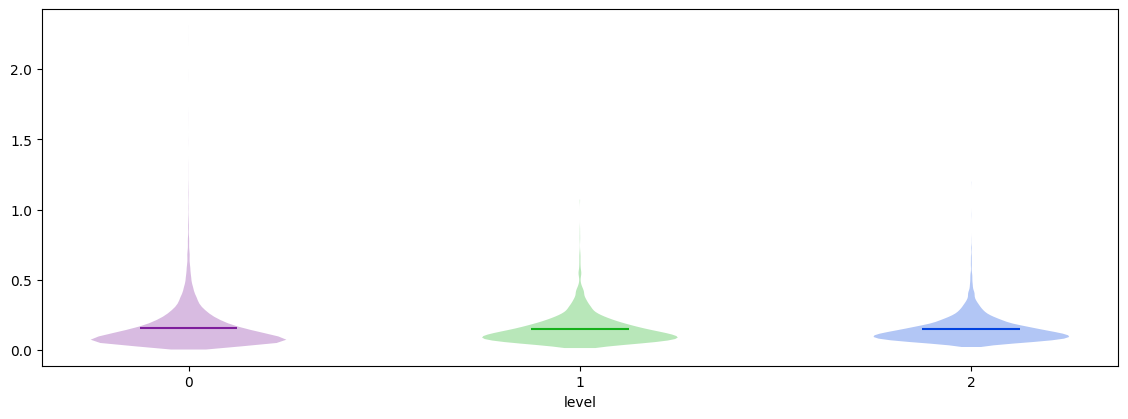

In [14]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(WIDTH,WIDTH/num_levels))
for l in range(num_levels):
    ax.violinplot(fgp.y[l],[l],showmeans=True,showextrema=False)
ax.set_xlabel("level")
ax.set_xticks(torch.arange(num_levels));